# Local Two-Dimensional Ground-Penetrating Radar Experiments And Field-Data Readiness

Generated: 2026-06-19.

## Executive Summary

Notebook `007` established the main state of the synthetic coordinate-optimizer
archive through output experiment 1259: the optimizer usually recovered the
known geometry, but many exact recoveries still had weak objective margins. In
that canonical milestone set, `433` of `442` parseable rows
preserved exact geometry, while `275` cleared the strict margin
cutoff.

The current batch did not overturn that conclusion. Its main contribution is
more specific: it stress-tested close-spacing acquisition choices, showed that
saved detector evidence is useful as a guardrail rather than a deployable
selector, diagnosed the remaining fixed-radius close14 failure mode, and
validated one narrow branch-locking mechanism in a guarded run.

The measured-field work reached a separate checkpoint. The current GSSI 51600s
archive supports selected two-dimensional quality-control statements, but it is
not ready for field full-waveform inversion, calibrated radius/depth recovery,
three-dimensional high-performance-computing work, or broad graphics-processor
runs. The next field step is controlled two-dimensional collection with known
target truth, references, profile geometry, repeats, and complete metadata.


## Scientific Objective

The project studies how reliably ground-penetrating radar can distinguish
closely spaced reinforcing bars in concrete. The central question is not simply
whether a rebar can be detected. The more specific question is whether the
inversion can distinguish the true geometry from nearby wrong geometries when
multiple rebars are close enough that their radar responses overlap.

This distinction matters because an inversion can return the correct geometry
while still having a weak margin over a nearly equivalent wrong geometry. Such a
case is useful evidence for ambiguity, but it should not be reported as a clean
resolution result.


## Methods And Terms

| Term | Meaning in this report |
| --- | --- |
| Ground-penetrating radar | A radar method that sends a short electromagnetic pulse into a material and records reflections from embedded objects such as steel reinforcement. |
| Synthetic experiment | A computer-generated radar experiment with known rebar position, depth, and radius. It is used to test whether the inversion returns the known truth. |
| Measured-field experiment | A real data experiment from the local GSSI 51600s archive. The true target geometry and timing references are not automatically known. |
| Finite-difference time-domain simulation | A numerical wave-propagation method used here to generate radar-like waveforms for candidate rebar geometries. |
| Full-waveform inversion | An optimization approach that compares simulated waveforms with observed waveforms and adjusts the model to reduce the mismatch. |
| Parametric inversion | An inversion that estimates a small set of parameters, such as rebar horizontal position, depth, and radius. |
| Objective margin | The score gap between the selected geometry and the nearest competing geometry. A small margin indicates ambiguity. |
| Candidate solution | One tested rebar geometry, or one tested combination of rebar geometries, that the optimizer or detector can rank against alternatives. |
| Top-1 and top-50 recovery | Top-1 means the true candidate is ranked first. Top-50 means the true candidate appears somewhere within the 50 best-ranked candidates. |
| Guardrail | A check that can flag reliable or risky cases before a larger inversion run. In this report, a guardrail is not the same as an automatic launch policy. |
| Transmitter-receiver offset | The distance between the transmitting antenna position and receiving antenna position. Some labels abbreviate this as Tx/Rx offset. |
| Two-dimensional (2D) | A cross-sectional model or line-profile interpretation with horizontal position and depth, but not a full volume. |
| Three-dimensional (3D) | A volumetric survey or inversion design. The local GSSI field archive is not treated as a 3D survey in this report. |
| Graphics processing unit (GPU) | The accelerator used for guarded simulation or optimization runs on the local workstation. |
| High-performance computing (HPC) | Cluster-scale computing, distinct from the local workstation. |
| GSSI 51600s archive | The local measured-field data set used in the field-data track. GSSI is the instrument/archive label; 51600s is the local session identifier. |


### Figure 1. Final Close-Spacing Synthetic Geometry

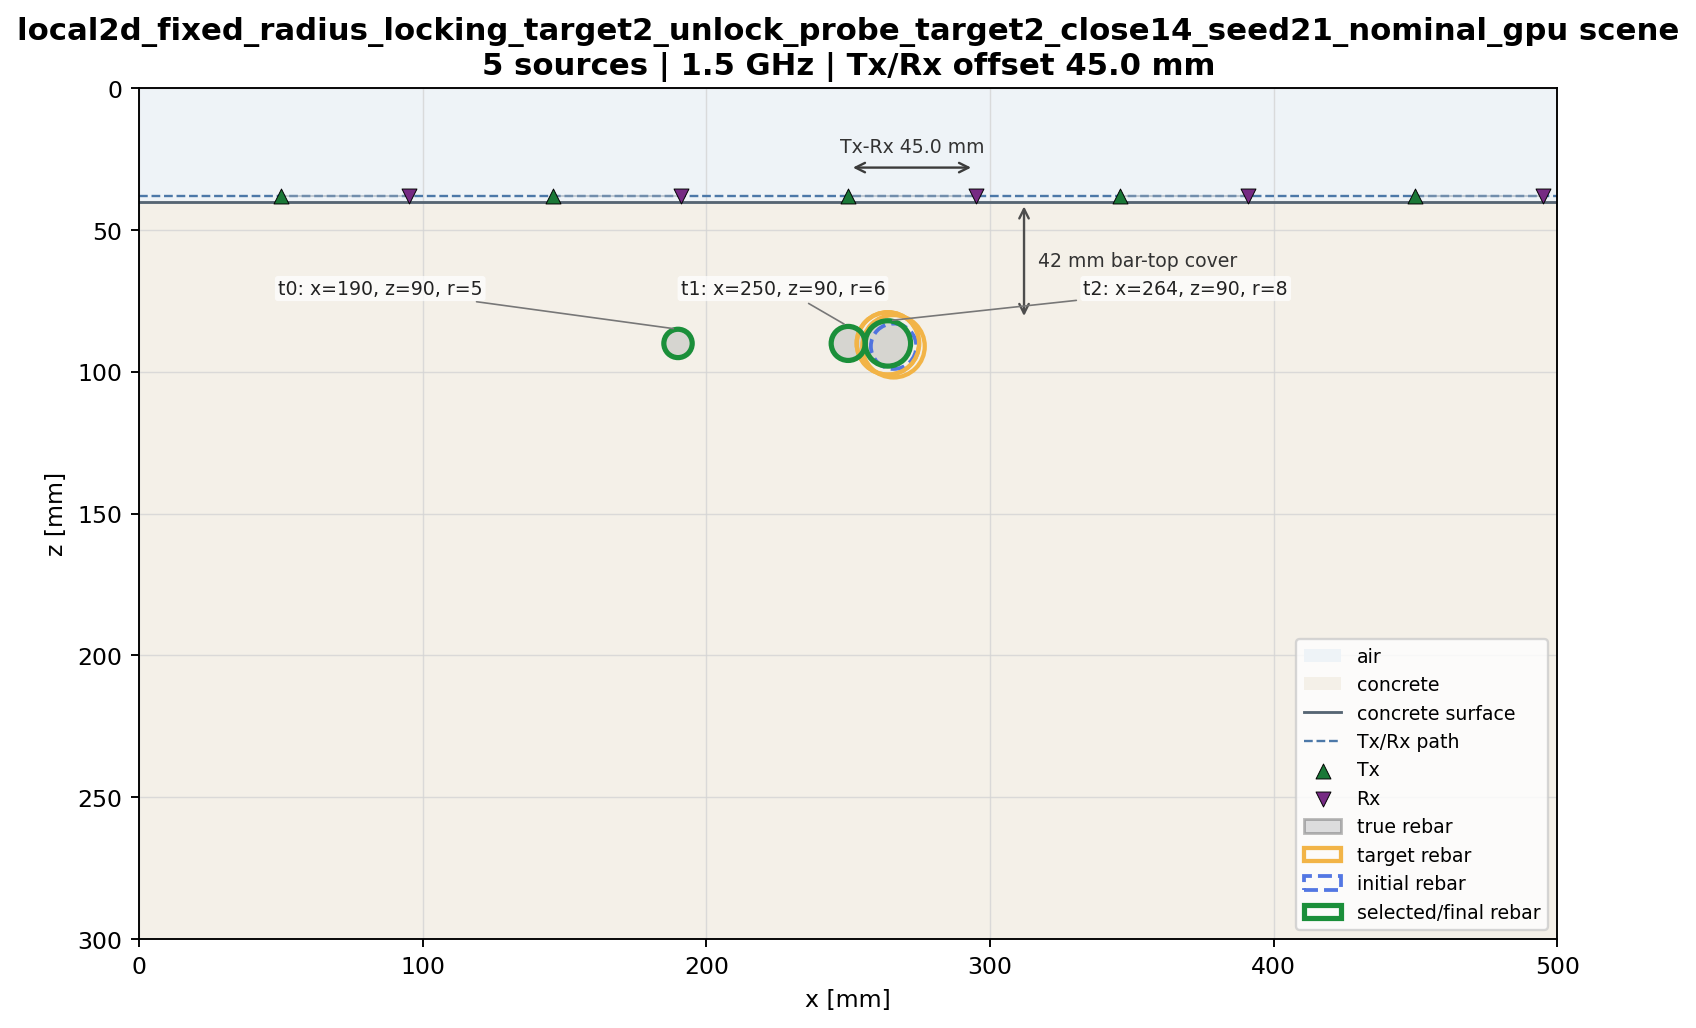

*Figure 1. This scene comes from output experiment 1358. The horizontal axis is lateral position in millimeters and the vertical axis is depth in millimeters. The final validation uses three rebars, with the center and right rebars separated by 14 mm center-to-center. Because their radii are 6 mm and 8 mm, their cross sections touch in this two-dimensional model. This figure explains why the close14 case is a difficult ambiguity test rather than a routine localization case.*

## Interpreting The Final Experiment Name

The final validation run is:

`1358_local2d_fixed_radius_locking_target2_unlock_probe_target2_close14_seed21_nominal_gpu`

| Name part | Meaning |
| --- | --- |
| local2d | A local two-dimensional synthetic experiment, not a measured-field run. |
| fixed_radius | The rebar radii are treated as known values, so the experiment isolates position ambiguity. |
| target2 | The final optimization step is focused on the right rebar in the three-rebar scene. |
| close14 | The center and right rebar centers are 14 mm apart in horizontal position. Here target1 has radius 6 mm and target2 has radius 8 mm, so their radii sum to 14 mm. That makes this a deliberately hard close-spacing case. It is not the transmitter-receiver offset. |
| seed21 | The repeatable random-noise setting used for this synthetic test. |
| nominal | The run uses the intended source model, rather than a source-mismatch stress test. |
| gpu | The guarded run used the local graphics processing unit while staying under the resource limits. |


### Figure 2. Prior Milestone Versus Current Coordinate-Optimizer Margins

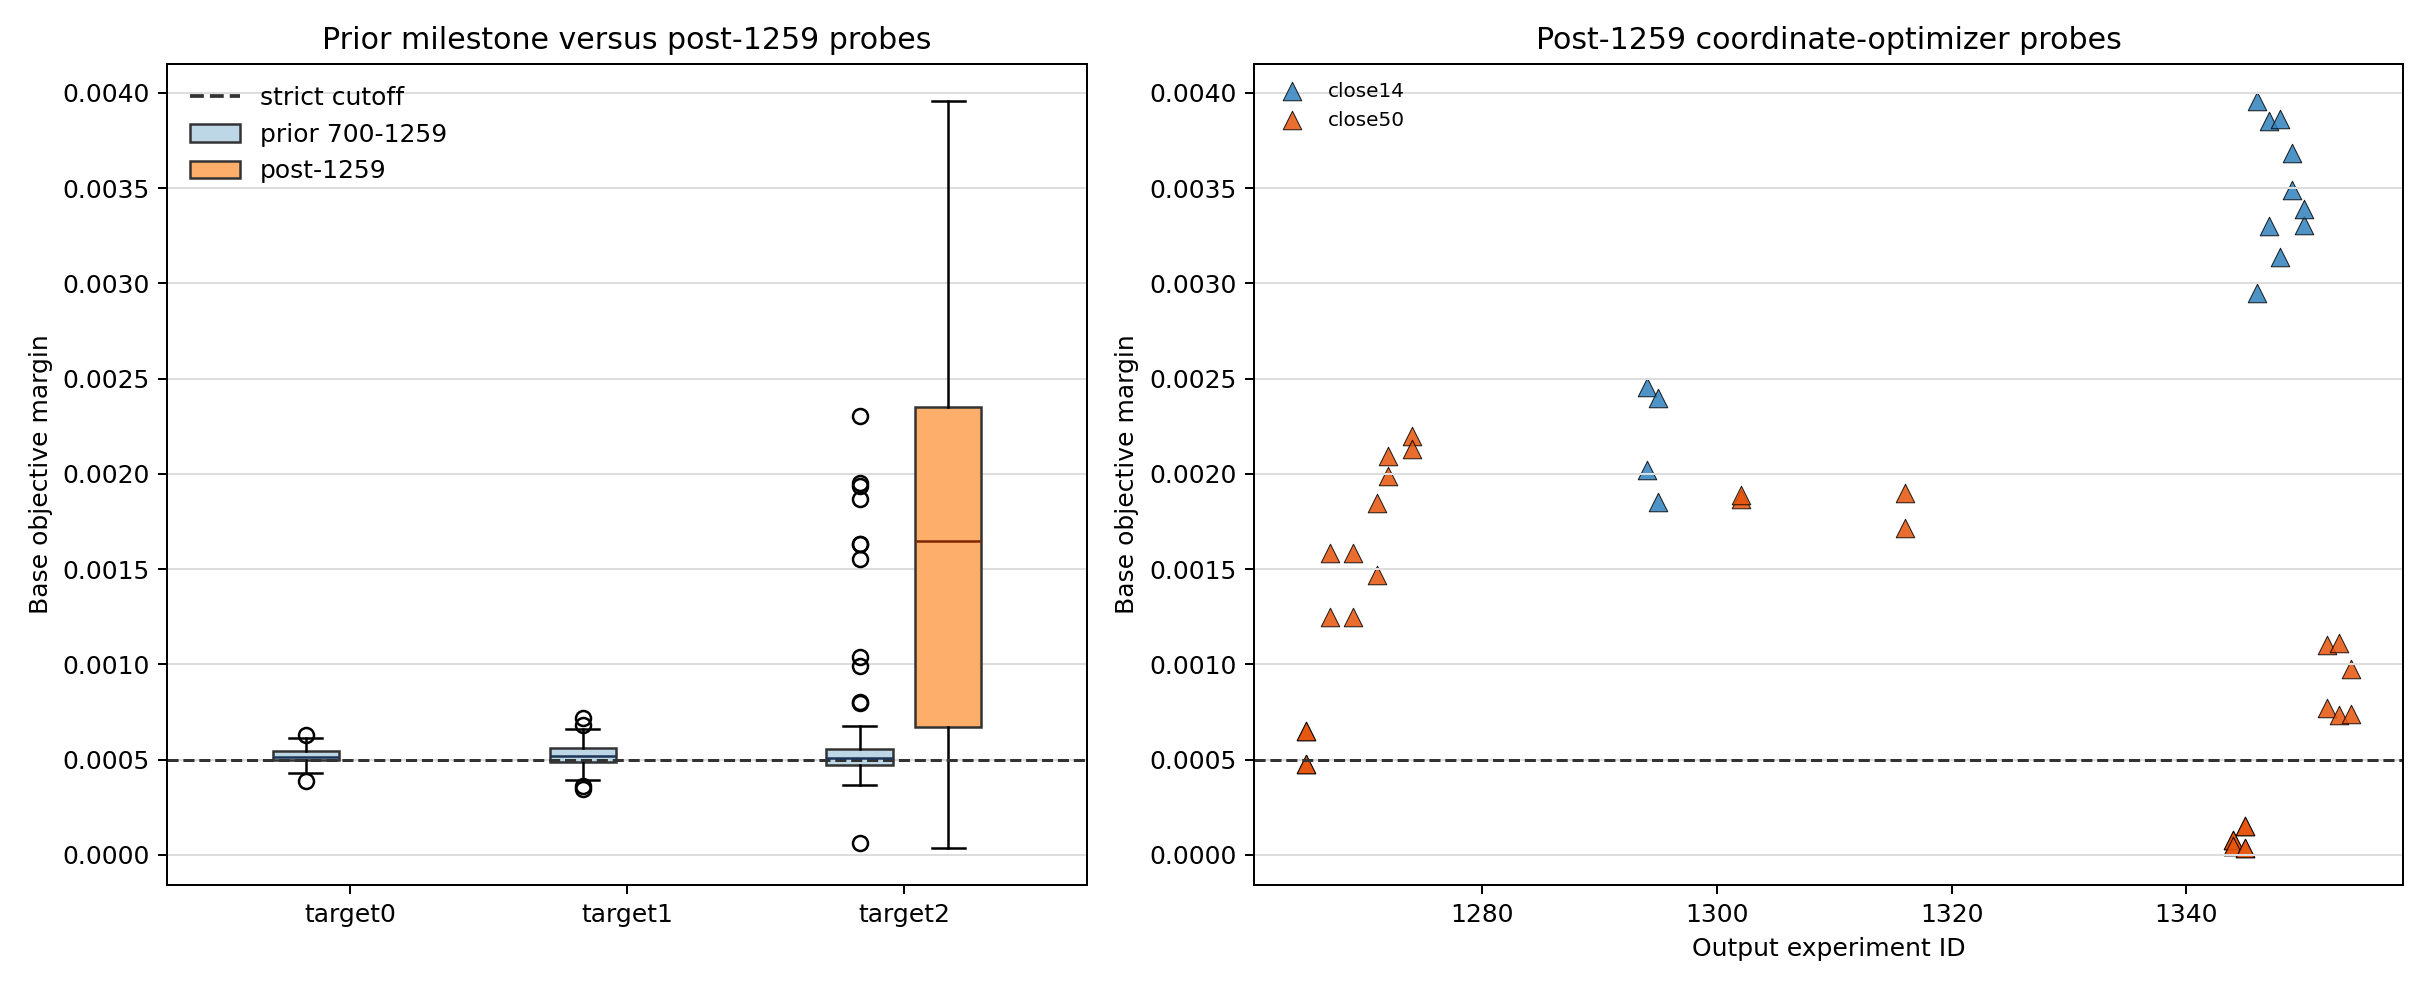

*Figure 2. The left panel compares the base objective margin distributions from the prior milestone notebook 007, experiments 700-1259, with post-1259 coordinate-optimizer probes. The dashed horizontal line is the strict 5.0e-4 confidence cutoff; values above it are stronger separations from the nearest candidate radius. The right panel shows each post-1259 coordinate-optimizer probe by experiment ID and target. The current batch remains concentrated around the same cutoff boundary, so it mainly confirms and refines the prior ambiguity boundary rather than producing a broad new improvement.*

## What Changed After Notebook 007

Notebook `007` had already shown that geometry recovery was strong but
confidence separation was incomplete. The post-1259 coordinate-optimizer probes
therefore tested boundary conditions rather than starting from scratch.

Across the post-1259 coordinate-optimizer rows with a base-margin value,
`36` of `46` cleared the strict cutoff. The strongest
post-1259 row in this parsed set is output experiment `1346`,
scenario `close14`, target `2`,
with margin `3.958e-03`. That best row is useful,
but the broader pattern in Figure 2 is more important: many newer close-spacing
tests remain near the cutoff, so the current batch mainly refines the resolution
boundary rather than replacing it.


### Figure 3. Post-1259 Close-Spacing Setup Outcomes

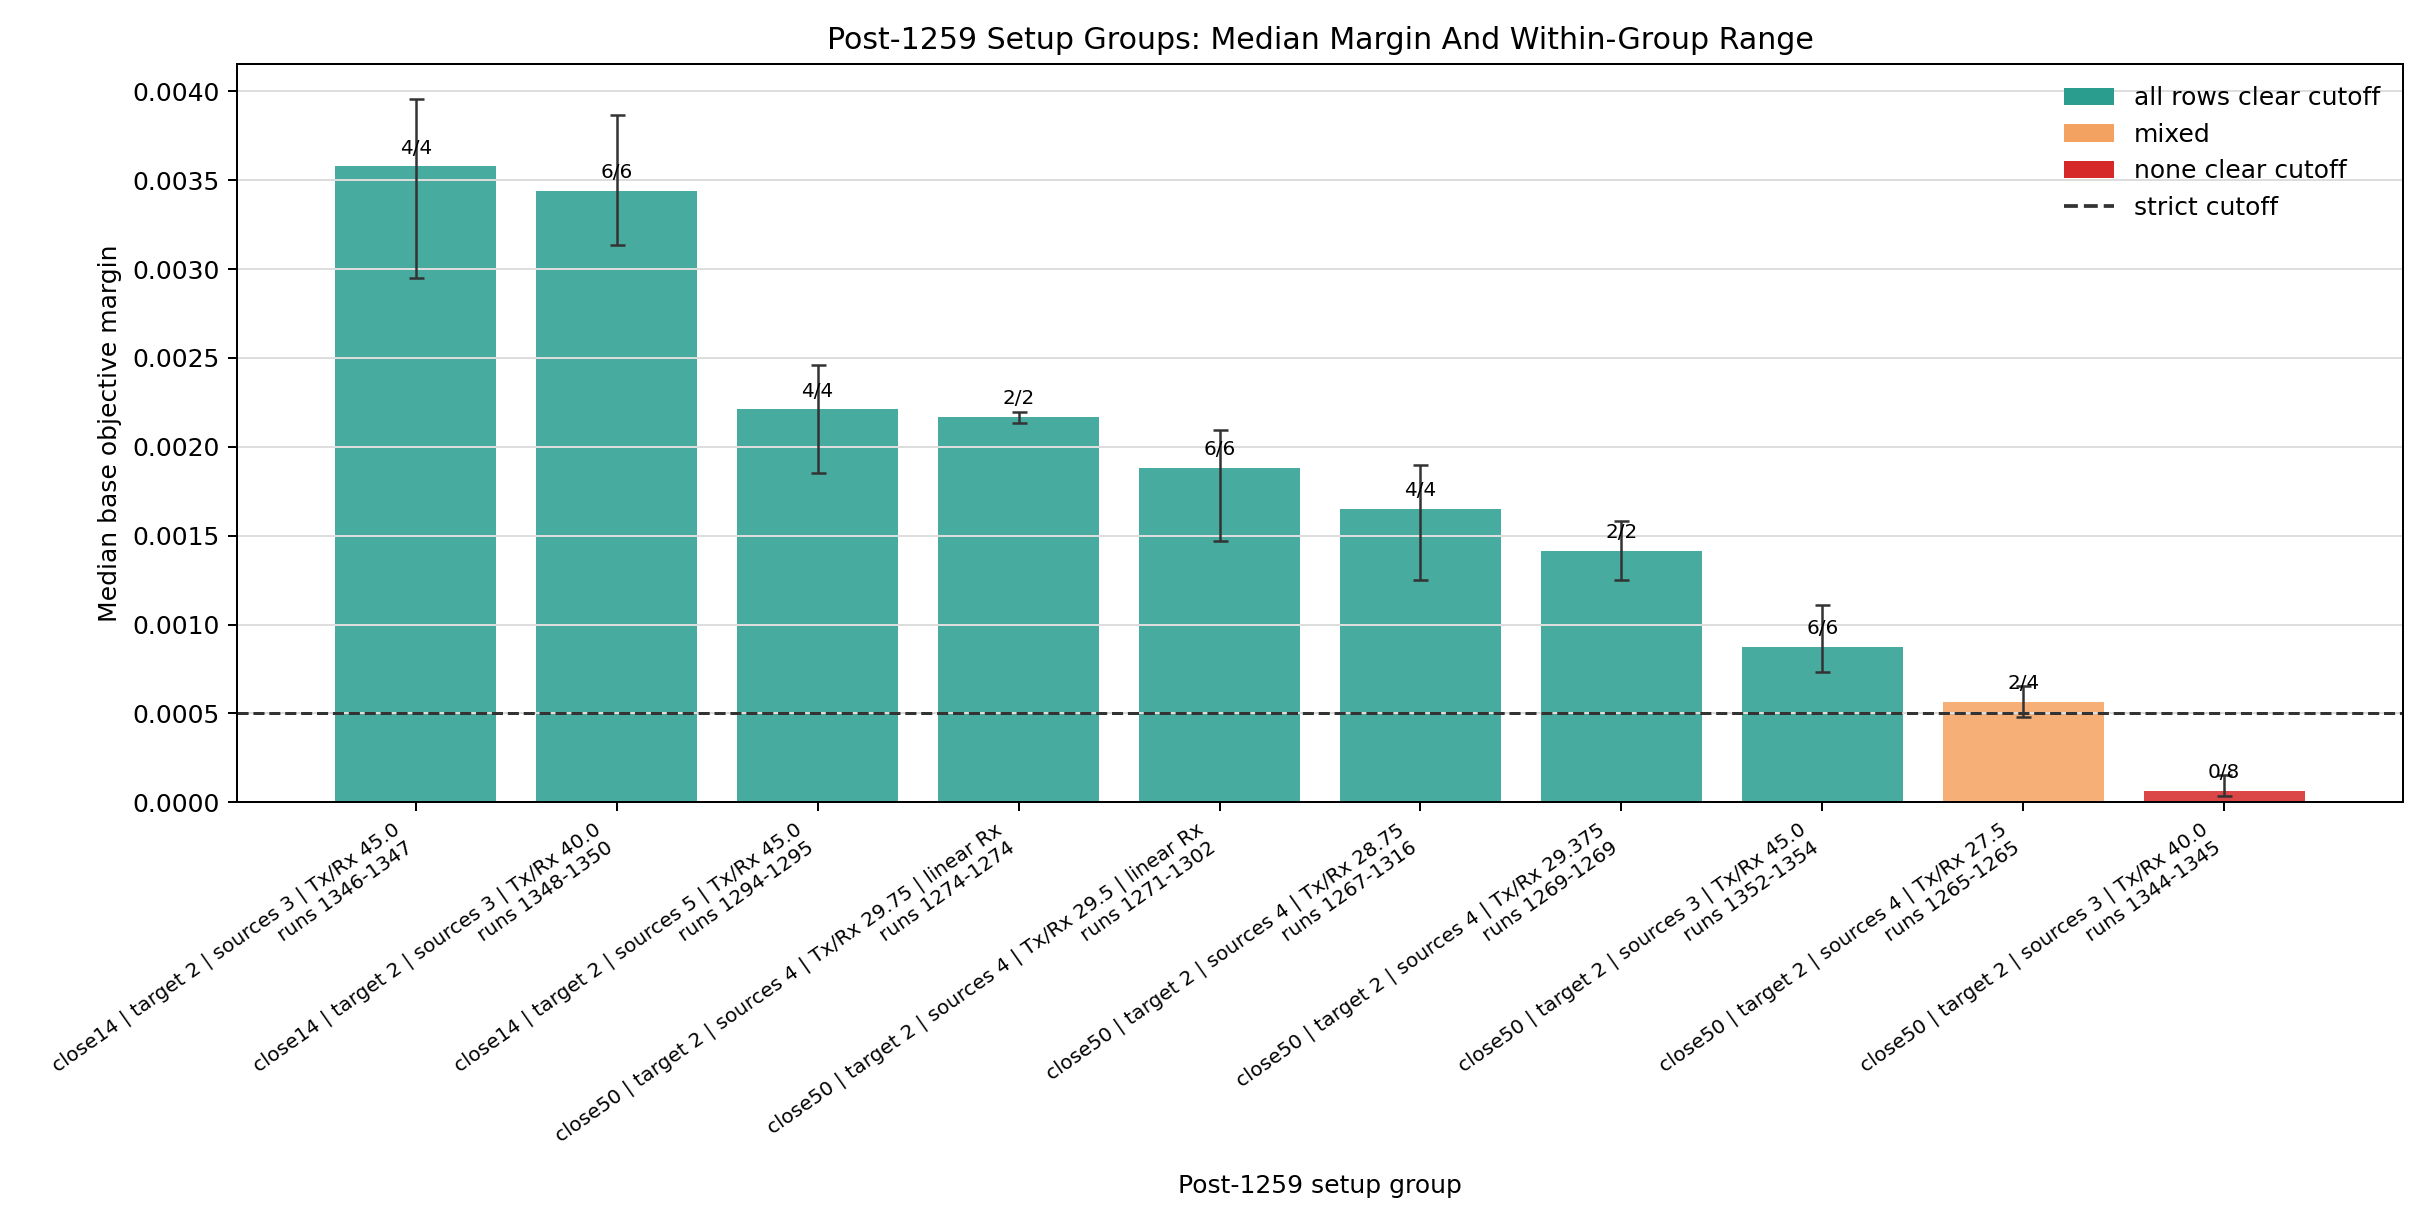

*Figure 3. Each bar is a setup group aggregated from post-1259 coordinate_confidence_report.csv rows. The y-axis is the median base objective margin, and the error bar spans the weakest to strongest row in that group. The dashed line is the strict 5.0e-4 confidence cutoff. The number above each bar is accepted rows over total rows; green means every row cleared the cutoff, orange means mixed behavior, and red means no row cleared the cutoff. The labels give spacing family, target, source count, transmitter-receiver offset, receiver sampling when relevant, and the experiment-ID range. This plot shows which newer close-spacing acquisition choices improved confidence and which stayed weak or unstable.*

## Close-Spacing Interpretation

The post-1259 close-spacing runs did not create a universal clean-spacing rule.
Instead, they showed that the outcome depends on acquisition setup, target,
source count, receiver sampling, and noise/source condition. Some close-spacing
rows clear the margin cutoff, while others remain weak even when the selected
geometry is correct.

That is a useful result. It supports a paper framing around acquisition-aware
identifiability: the method can often recover the right geometry, but the margin
must be checked before calling a case resolved.


### Figure 4. Fixed-Radius Branch Progression And Remaining Ambiguity

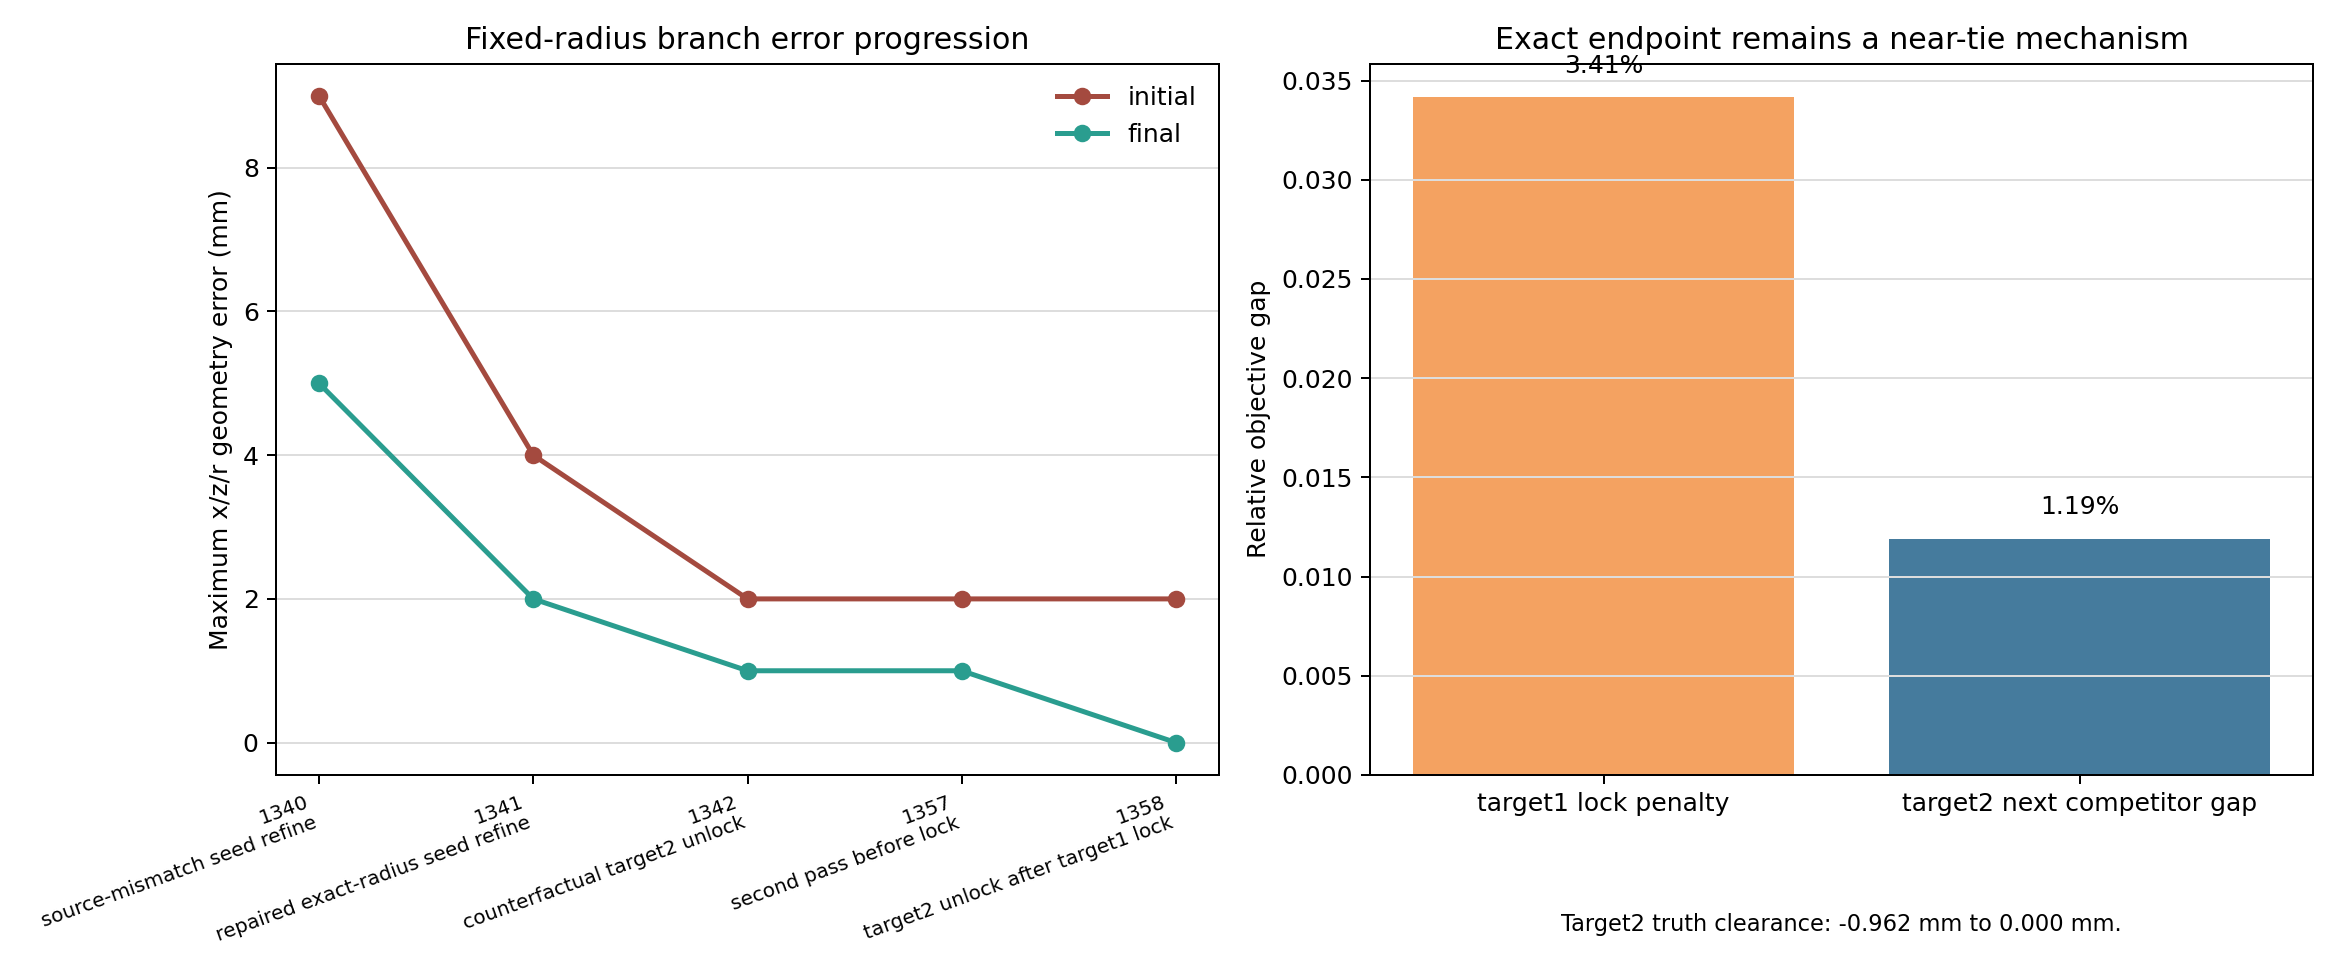

*Figure 4. The left panel plots the maximum geometry error, in millimeters, for the fixed-radius close14 branch stages. The final guarded validation, experiment 1358, reaches zero final error. The right panel plots relative objective gaps: the target1 lock required a 3.41 percent relative objective penalty, and the exact target2 endpoint still had a close next competitor with a 1.19 percent relative gap. The conclusion is that the branch-locking mechanism worked, but it remains a narrow near-tie result rather than a broad detector-policy result.*

## Fixed-Radius Mechanism Result

The fixed-radius sequence narrowed a specific failure mode. Before locking, the
branch could end with a 1 mm residual because the center rebar and right rebar
were coupled by a near-tie geometry. The CPU-side policy selected a target1 lock
at x=250 mm, z=90 mm. That lock changed target2 truth clearance from
`-0.962` mm to
`0.000` mm, and the
guarded target2 unlock probe ended with
`0.0` mm maximum
geometry error.

The result is reportable, but the claim must stay narrow:

- Supported: this fixed-radius close14 branch can be repaired by a specific
  target1 lock and target2 unlock sequence.
- Not supported: a general detector policy.
- Not supported: detector-seeded full-waveform inversion.
- Not supported: direct transfer of this synthetic mechanism to measured field
  data.


### Figure 5. Detector Evidence Progression

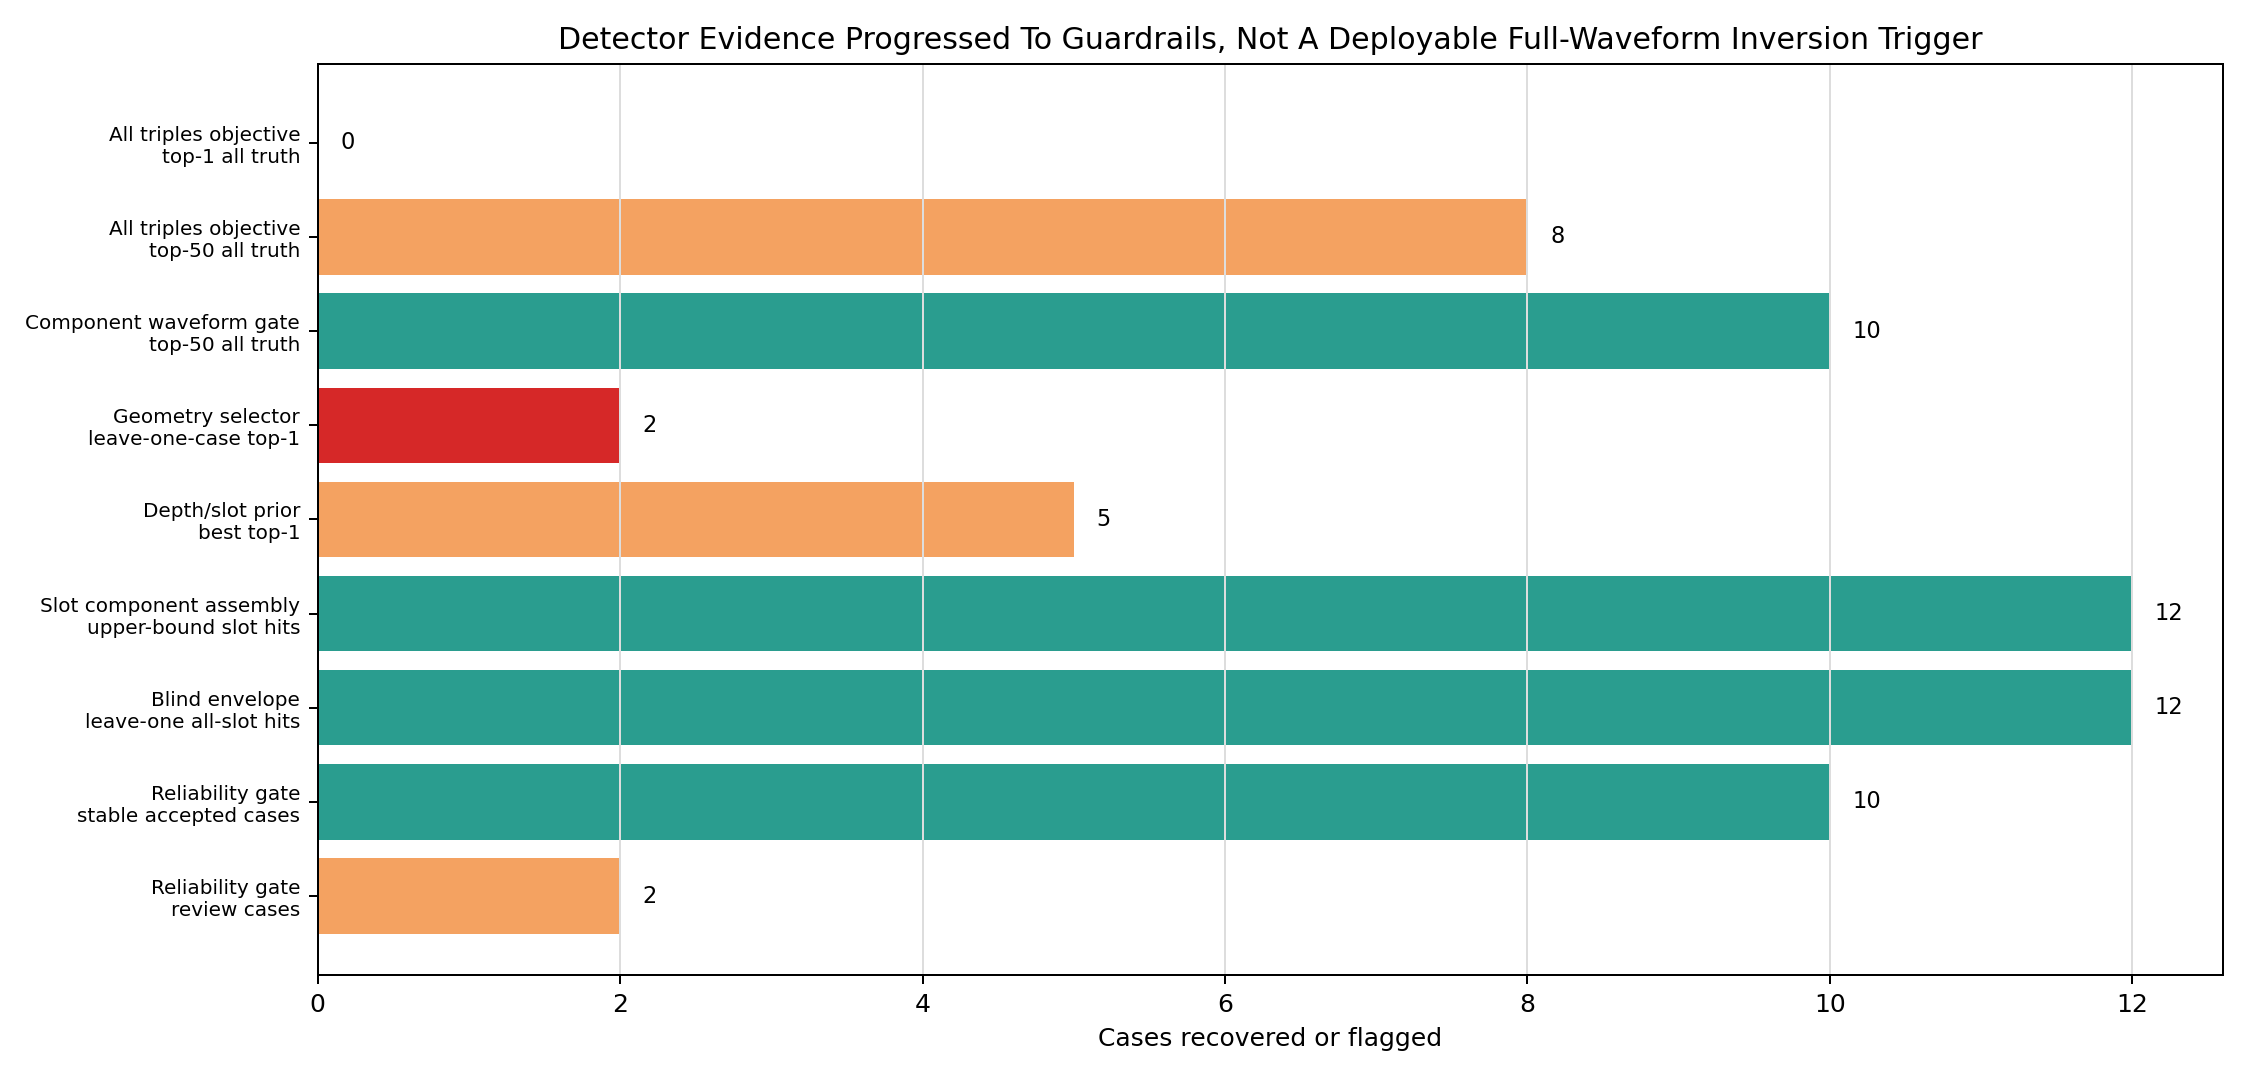

*Figure 5. Bars summarize detector-side metrics from the current manuscript table pack. The y-axis lists successive detector or selector analyses; the x-axis is the number of cases recovered or flagged. Top-1 means the true candidate was ranked first; top-50 means it appeared somewhere within the 50 best-ranked candidates. The detector evidence improves from weak top-1 all-truth recovery to useful upper-bound and reliability-gate evidence, but it still does not justify detector-seeded full-waveform inversion because the robust output is a guardrail and seed table, not a complete deployable selector.*

## Detector Interpretation

The detector studies are useful because they identify where candidate selection
is stable and where it should be reviewed. They do not yet provide a complete
inversion launch contract. The all-triples objective remains weak at top-1
selection, while later blind-envelope and reliability-gate analyses recover or
screen more cases. That progression supports detector guardrails and
upper-bound statements, but not a broad full-waveform inversion launch.


### Figure 6. Measured-Field Archive Readiness

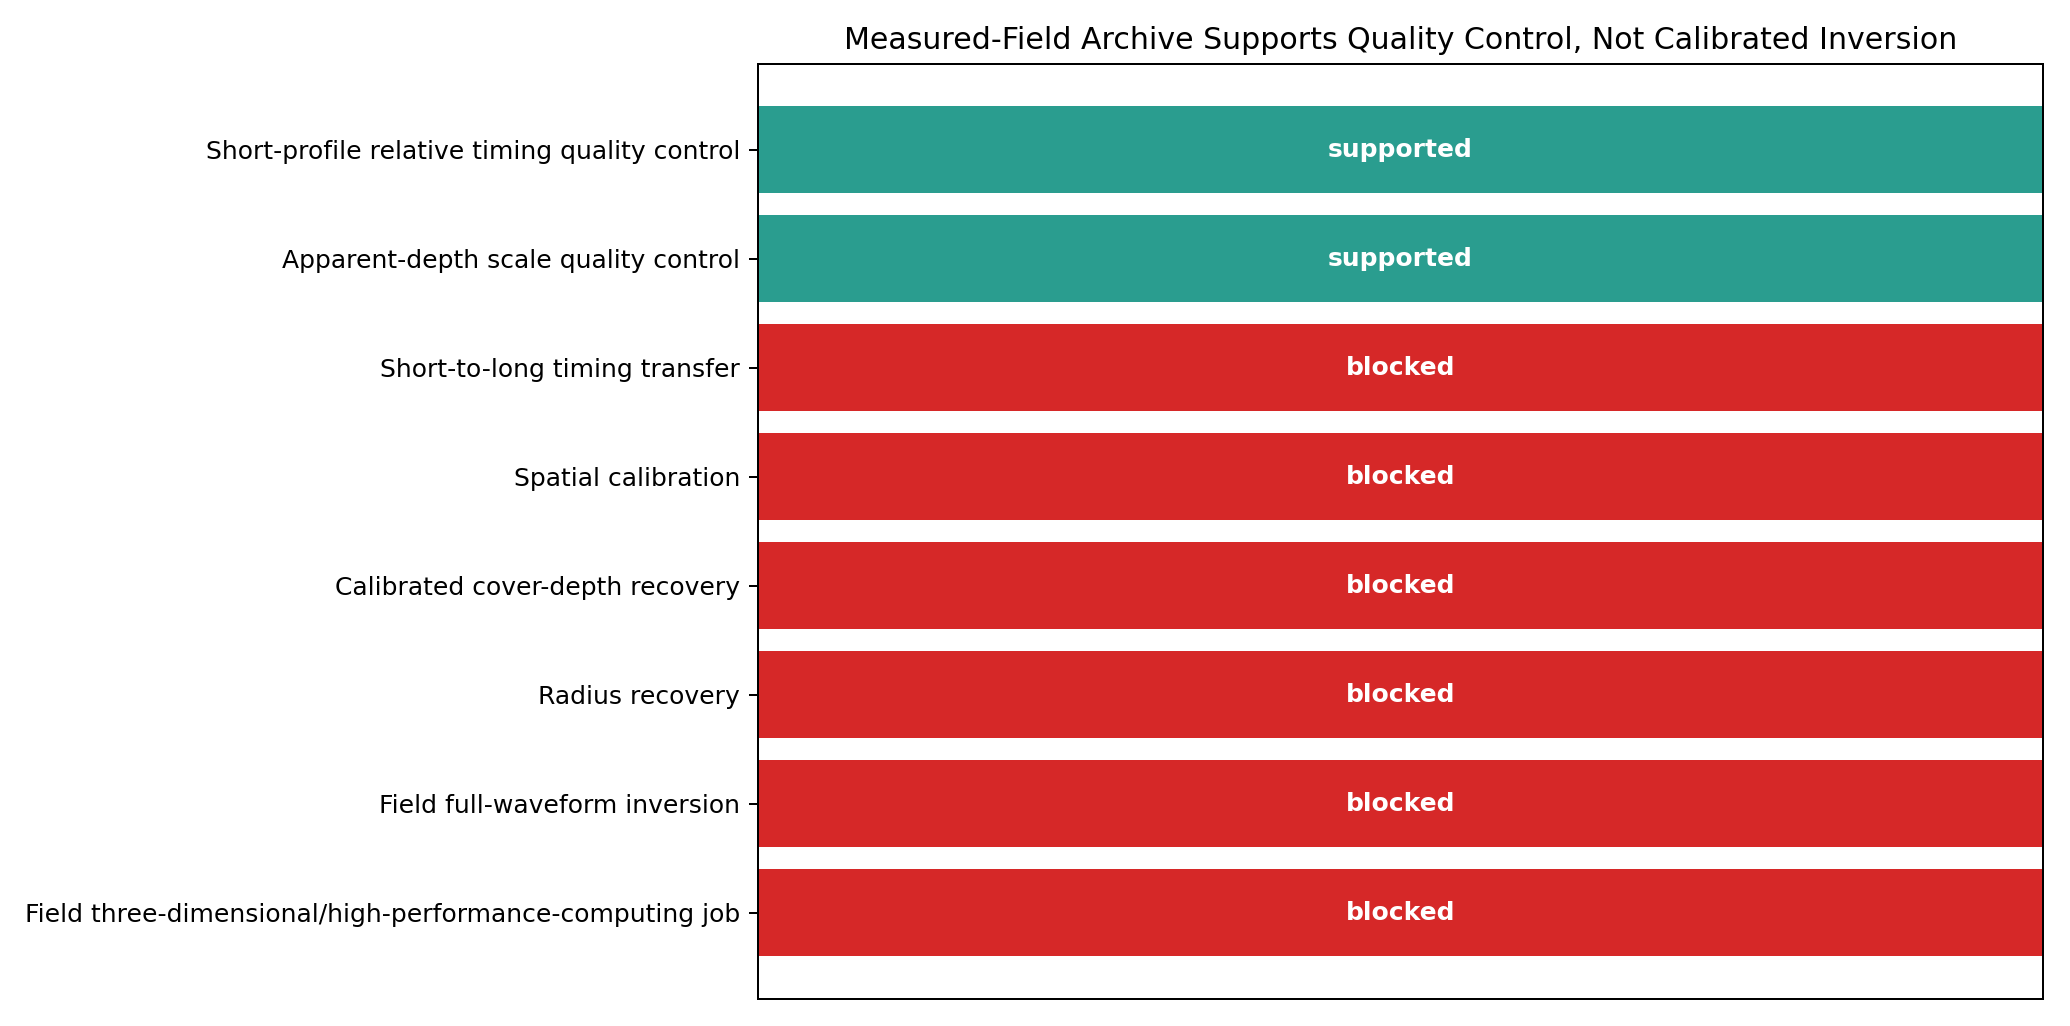

*Figure 6. Each row is a field-data capability from the current readiness metrics. Green rows are supported by the current archive and red rows are blocked. The current field archive supports short-profile relative timing quality control and apparent-depth scale quality control, but blocks timing transfer, spatial calibration, calibrated cover-depth recovery, radius recovery, field full-waveform inversion, and field three-dimensional or high-performance-computing escalation.*

### Figure 7. Field Acceptance Gate Blockers

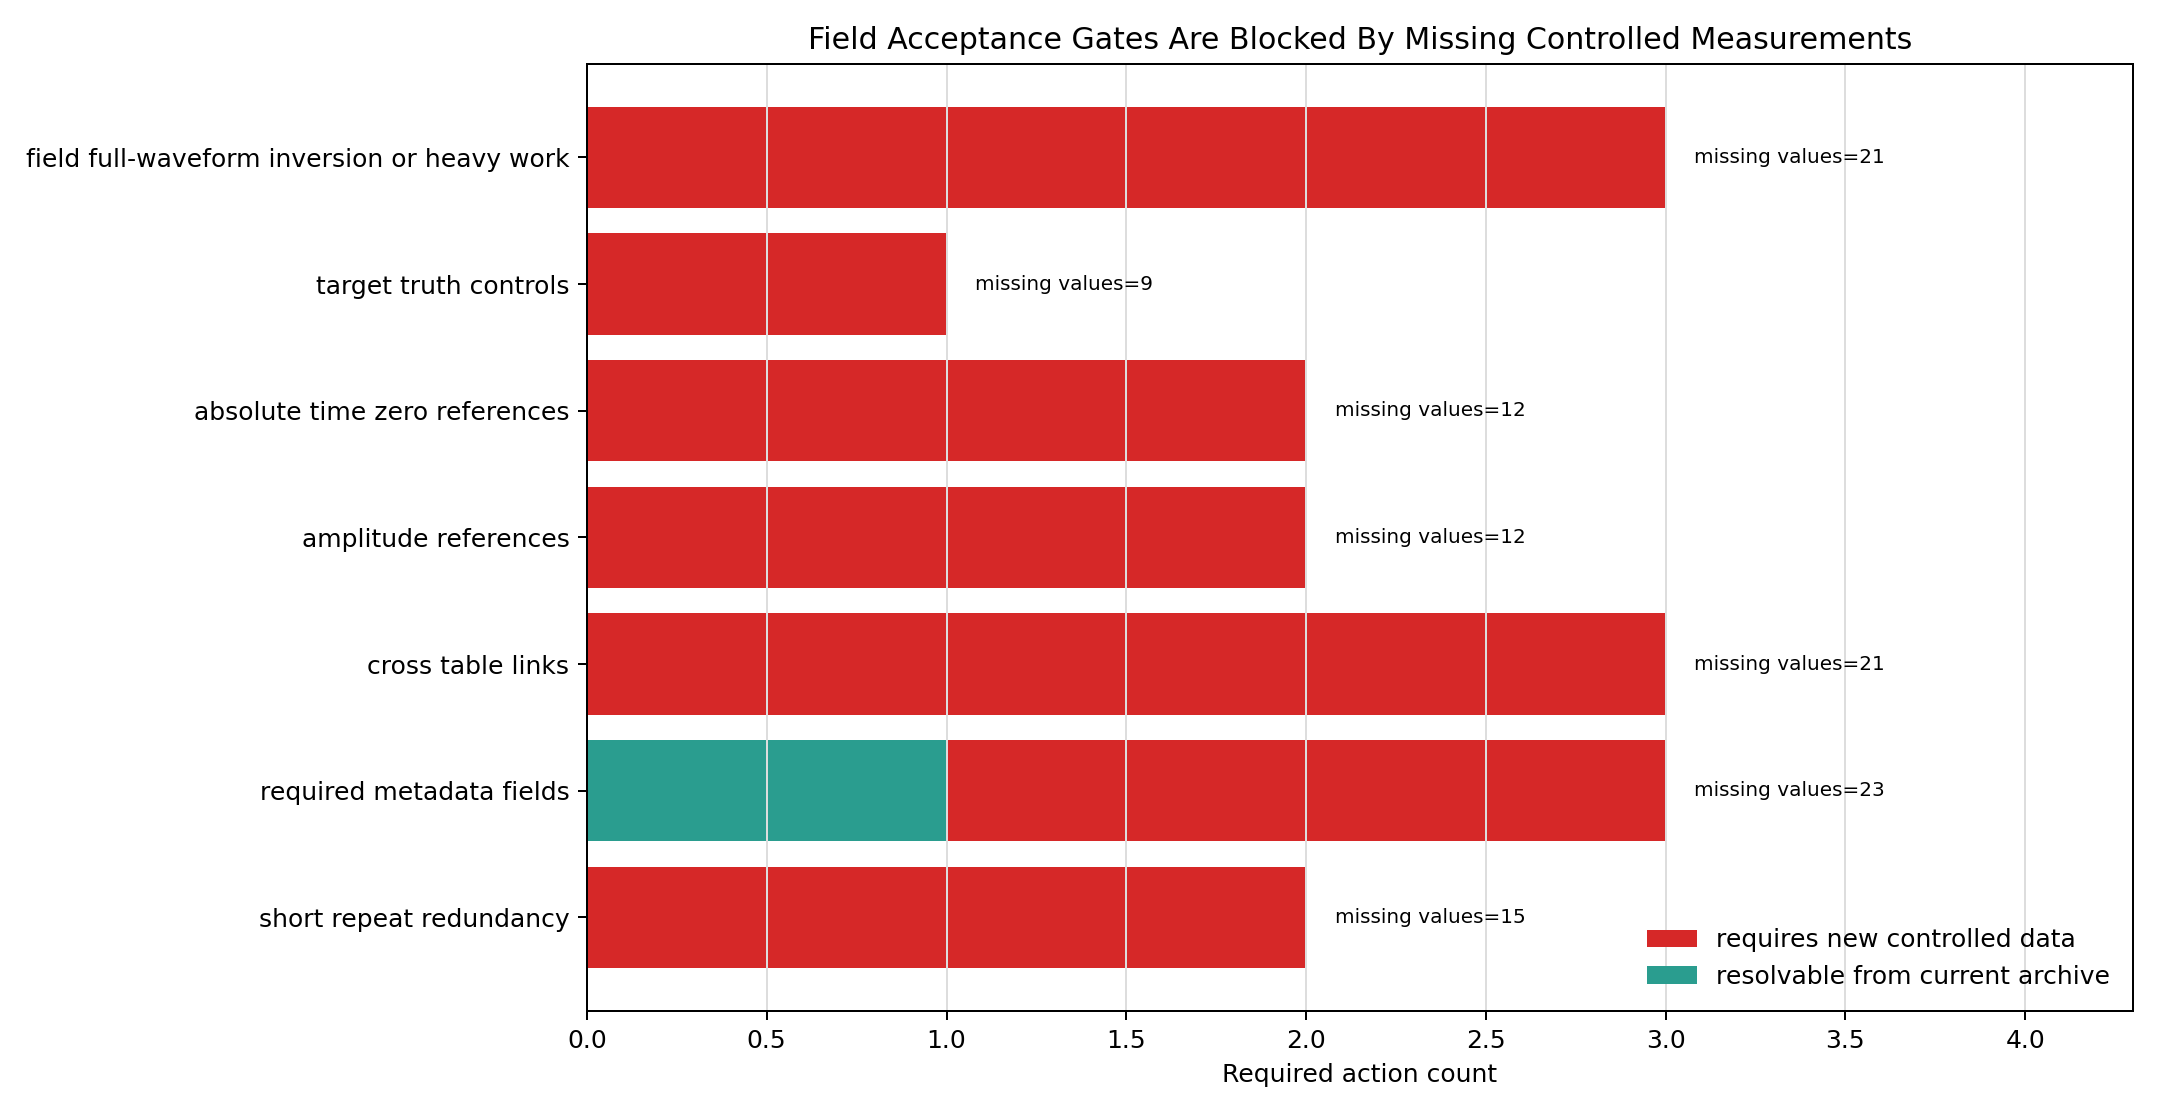

*Figure 7. Each horizontal bar is an acceptance gate from field run 156. The x-axis is the number of required action groups. Red portions require new controlled data; green portions would be resolvable from the current archive. The labels show missing required metadata values. The current archive cannot unblock the field acceptance gates by itself, especially the field full-waveform inversion or heavy-work gate.*

## Field-Data Interpretation

The field data are valuable, but the supported claims are currently limited to
quality control and collection planning. The data are independent two-dimensional
line profiles, not a three-dimensional survey. Without known target truth,
absolute time-zero references, amplitude references, profile-target geometry,
repeat measurements, and complete metadata, field full-waveform inversion would
be underconstrained.


### Figure 8. Controlled Field Collection Requirements

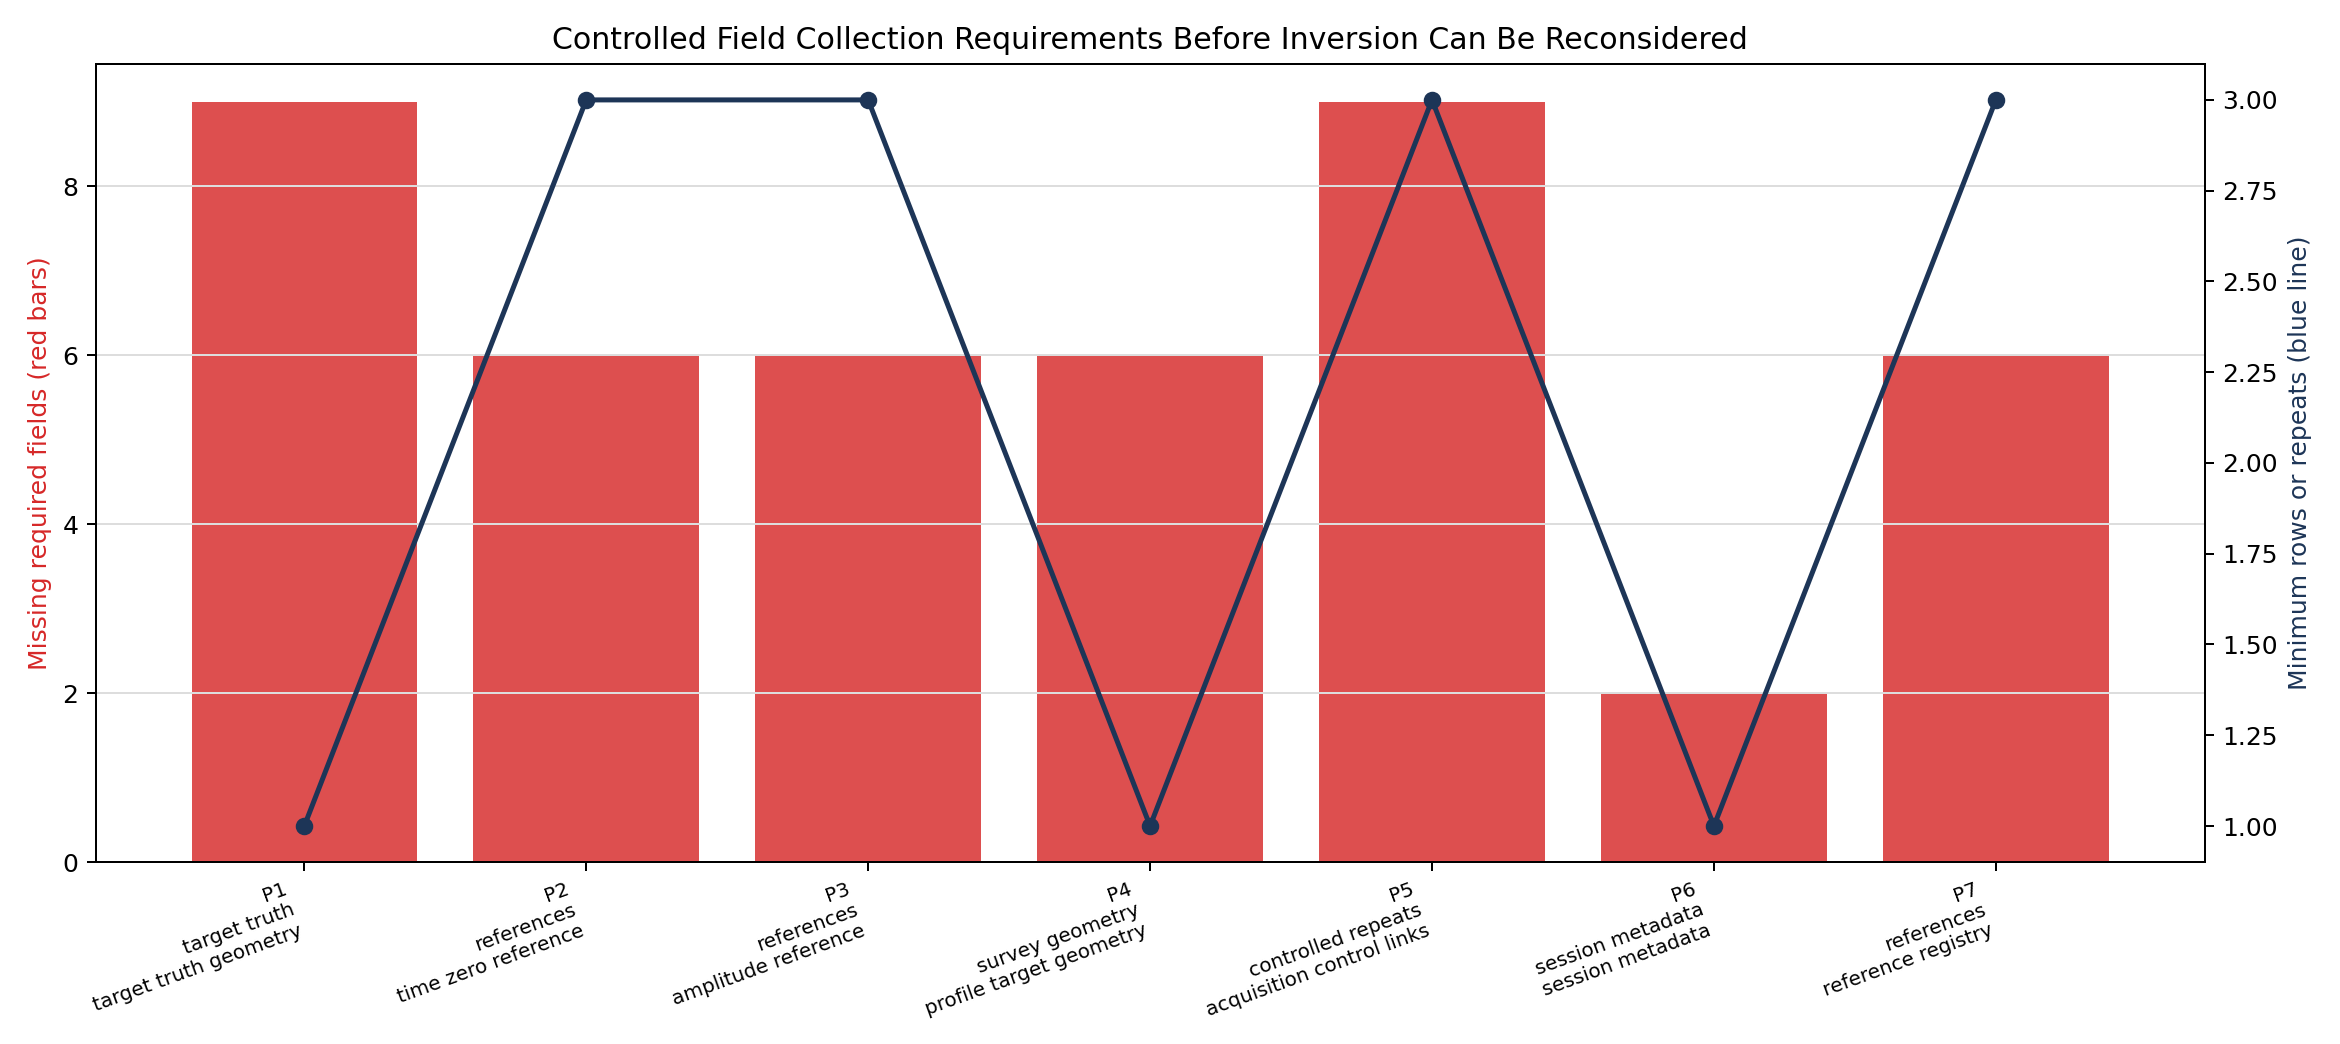

*Figure 8. Each bar is a required field action from run 156, ordered by priority. Red bars show missing required values; the blue line shows the minimum number of rows or repeats needed for that action. The plot shows that the next field milestone is controlled two-dimensional collection, not immediate inversion.*

## Required Field Work Before Inversion

The next field work should collect the missing controls and then re-run the
acceptance gates. The highest-priority requirements are target truth, time-zero
references, amplitude references, survey geometry, controlled repeats, session
metadata, and reference registry rows.

| Priority | Phase | Blocker | Planned IDs or repeats | Minimum | Done when |
| --- | --- | --- | --- | --- | --- |
| 1 | target_truth | target_truth_geometry | T_CONTROL_001 | 1 | target_truth row has material, center coordinates, cover depth, diameter/radius, dielectric/velocity, uncertainty, and truth source |
| 2 | references | time_zero_reference | T0_REF_001,T0_REF_002,T0_REF_003 | 3 | at least three metal-plate or air/direct references have measured time-zero and uncertainty no larger than the stated gate |
| 3 | references | amplitude_reference | AMP_REF_001,AMP_REF_002,AMP_REF_003 | 3 | at least three amplitude-reflector references have amplitude metrics and repeatability |
| 4 | survey_geometry | profile_target_geometry | P_CONTROL_001:T_CONTROL_001 | 1 | profile start/end, scan direction, trace spacing, crossed target IDs, and survey method are recorded in one profile-to-target coordinate frame |
| 5 | controlled_repeats | acquisition_control_links | P_CONTROL_001:repeat1,P_CONTROL_001:repeat2,P_CONTROL_001:repeat3 | 3 | three controlled repeats have file names, Tx/Rx offset, coupling condition, target/profile links, and before/after reference IDs |
| 6 | session_metadata | session_metadata | planned_controlled_2d_session_001 | 1 | session date and operator are verified or recollected |
| 7 | references | reference_registry | AMP_REF_001,AMP_REF_002,AMP_REF_003,T0_REF_001,T0_REF_002,T0_REF_003 | 3 | every reference row has file name, expected response, repeat ID, and session link |


## Publication Positioning

The defensible contribution is an acquisition-aware identifiability study for
closely spaced rebars. The paper should emphasize when the true geometry is
distinguishable from nearby alternatives, when that distinction becomes
ambiguous, and why measured-field data require controlled references before
inversion.

The paper should not claim that all close-spacing cases are cleanly resolvable,
that the detector is deployable as a general policy, or that the local field
archive is ready for field full-waveform inversion.

Selected claim boundaries:

| Domain | Claim area | Use tier | Allowed claim | Not allowed |
| --- | --- | --- | --- | --- |
| field_2d | field_geometry | field_supplement_guardrail | The local GSSI data are independent 2D line-profile QC evidence. | Do not treat the dataset as a recovered 3D survey grid without external layout metadata. |
| field_2d | short_profile_timing | field_supplement_result | Use short 014/016 content-backed and supported-stack figures for relative timing/repeatability QC. | Do not claim absolute time-zero, cover depth, radius, or measured-data FWI from these panels. |
| field_2d | long_profile_pattern | field_supplement_result | Use long 015/013 figures as pattern-only QC at the robust +0.06 ns shift. | Do not call the long-profile shift a phase anchor or transferable time-zero correction. |
| field_2d | synthetic_separation | guardrail | Keep field QC and known-truth synthetic confidence policies separate. | Do not use field QC to relabel synthetic optimizer success or ambiguity tiers. |
| field_2d | gpu_next_step | guardrail | No field GPU/FWI run is justified without external survey geometry or a new measured-data objective. | Do not launch field FWI/3D runs from this dataset alone. |
| field_2d | long_profile_sensitivity | field_supplement_guardrail | The +0.06 ns long-profile pattern-only support survives the tested shallow time windows and anchor widths. | Do not convert sensitivity robustness into absolute phase-anchor, cover-depth, radius, 3D, or FWI claims. |
| field_2d | long_relaxed_phase_anchor | field_supplement_guardrail | Use the relaxed long-profile phase-anchor audit as negative evidence: profile 013 candidates remain low-SNR and the long pair remains pattern-only QC. | Do not promote relaxed late-window picks to absolute time-zero, cover-depth, radius, 3D, or measured-data FWI evidence. |
| field_2d | field_bandlimited_repeatability | field_supplement_guardrail | Use the band-limited repeatability audit to justify measured-field QC band choices for the short pair and pattern-only band support for the long pair. | Do not convert band-limited repeatability into absolute time-zero, cover-depth, radius, 3D, or measured-data FWI evidence. |
| field_2d | field_event_support_tiers | field_supplement_guardrail | Use the event-support tier table to separate short-pair content-backed timing QC, long-pair pattern-only support, band-limited repeatability, and explicit FWI/3D blockers. | Do not convert event-support tiers into field radius, cover-depth, 3D, or measured-data FWI claims. |
| field_2d | field_time_zero_uncertainty_budget | field_supplement_result | Use the relative time-zero uncertainty budget for short 014/016 QC, robustness accounting, and manuscript uncertainty bounds. | Do not convert the relative uncertainty budget into absolute time-zero, field FWI, 3D, radius, or cover-depth claims. |
| field_2d | field_time_zero_perturbation_sensitivity | field_supplement_guardrail | Use the perturbation sensitivity audit to show that the short 014/016 B-scan QC remains supported under bootstrap-CI and conservative relative-offset perturbations. | Do not convert perturbation robustness into absolute time-zero, field FWI, 3D, radius, or cover-depth claims. |
| field_2d | field_early_time_anchor_negative_qc | field_supplement_guardrail | Use the early-time median-trace audit as a negative control showing that common-mode/direct-wave alignment does not reproduce the content-backed short-pair offset. | Do not use the early direct/ringdown component as an absolute time-zero calibration, field FWI anchor, 3D inversion input, or replacement for content-backed timing. |


## Recommended Next Steps

For synthetic two-dimensional work:

1. Treat the fixed-radius close14 endpoint as a bounded mechanism result.
2. Continue CPU-side confidence-policy synthesis before any new graphics-processor
   run.
3. If another synthetic run is justified, make it a single guarded probe with a
   predeclared hypothesis and a predeclared decision rule.

For measured-field work:

1. Keep the current field archive in the quality-control and planning lane.
2. Execute the controlled two-dimensional collection packet.
3. Collect known target truth, time-zero references, amplitude references, profile
   geometry, controlled repeats, and required metadata.
4. Re-run the field acceptance gates after collection before considering field
   inversion, heavy graphics-processor work, or high-performance-computing work.


## Source Artifacts

| Artifact | Path | Purpose |
| --- | --- | --- |
| Prior milestone notebook | docs/update/summary/007_2026-06-17_experiment_700_1259_holistic_evaluation.ipynb | Baseline result through output experiment 1259. |
| Current report notebook | docs/update/summary/015_2026-06-19_local_2d_field_standalone_report.ipynb | Result-focused synthesis of the current 2D and field checkpoint. |
| Current generated figures and tables | outputs/summary_tables/133_local_2d_field_holistic_report_post_checkpoint | Support files and regenerated report figures. |
| Final synthetic probe | outputs/experiments/1358_local2d_fixed_radius_locking_target2_unlock_probe_target2_close14_seed21_nominal_gpu | Evidence for the fixed-radius locking endpoint. |
| Field critical-path checkpoint | outputs/field_experiments/local_gssi_51600s_2026_06_09/156_gssi51600s_controlled_collection_critical_path | Evidence for the field collection-readiness checkpoint. |